# Comparison of the SSRV setup against the SSRH baseline setup

In [28]:
import pandas as pd;
import numpy as np;
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

path = '../../../../playwright/results/core-web-vitals/testrun-8/'

pd.set_option('display.float_format', lambda x: '%.2f' % x)
plt.rcParams.update({'font.size': 14})

features = ['navTime', 'totalTime', 'lcp', 'fcp', 'ttfb', 'tbt', 'tti', 'longestTask', 'longTasks', 'nf:init', 'nf:config', 'nf:loaded']

def detect_outliers(df, features, contamination=0.1):
    clf = IsolationForest(contamination=contamination, random_state=42)
    outliers = clf.fit_predict(df[features])
    return outliers == 1

## UNTHROTTLED Comparison

The outliers will be removed using the IsolationForest unsupervised model and by removing the first 5 cycles (JVM warmup)

In [29]:
target_features = ['ttfb', 'fcp', 'lcp', 'tbt']

dirty_dfs =	{
  "SSRH": pd.read_csv(f'{path}2024-12-17T11:09:51.655Z_results-ssrh-sd.csv', sep=','),
  "SSRV": pd.read_csv(f'{path}2024-12-17T16:46:34.776Z_results-ssrv-sd.csv', sep=','),
}

masks = {}
dfs = {}

for name, df in dirty_dfs.items():
    mask = detect_outliers(df, target_features)
    masks[name] = mask
    dfs[name] = df[mask].copy()

/var/folders/n3/c303nvyx3yv3x75n2g2xfh1h0000gn/T/ipykernel_8571/3428325343.py:10: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  axes[idx].set_ylim(0, max_height * 1.2)
/var/folders/n3/c303nvyx3yv3x75n2g2xfh1h0000gn/T/ipykernel_8571/3428325343.py:13: RuntimeWarning: invalid value encountered in scalar divide
  percentage = ((bar.get_height() / baseline) - 1) * 100


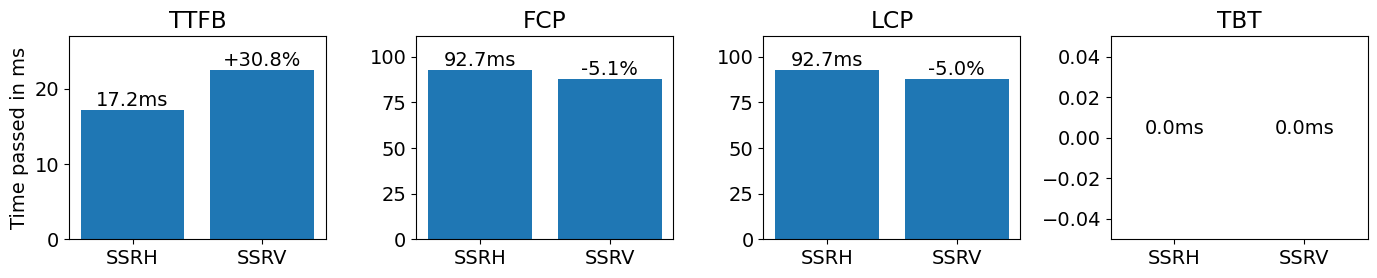

In [30]:
fig, axes = plt.subplots(ncols=len(target_features), figsize=(14, 3))
plt.subplots_adjust(hspace=0.3, wspace=0.3, top=0.95, bottom=0.05)

for idx, feature in enumerate(target_features):
    percentiles = {d: dfs[d][feature].quantile(0.75) for d in dfs}
    bars = axes[idx].bar(percentiles.keys(), percentiles.values())
    baseline = list(percentiles.values())[0]

    max_height = max(percentiles.values())
    axes[idx].set_ylim(0, max_height * 1.2)
    
    for i, bar in enumerate(bars):
        percentage = ((bar.get_height() / baseline) - 1) * 100
        label = f'{bar.get_height():.1f}ms' if (i == 0 or bar.get_height() == 0) else f'{percentage:+.1f}%'
        axes[idx].text(bar.get_x() + bar.get_width()/2., bar.get_height(), label, ha='center', va='bottom')
    
    axes[idx].set_title(feature.upper())
    if idx == 0:
        axes[idx].set_ylabel('Time passed in ms')

plt.tight_layout()
plt.show()

## THROTTLED Comparison


In [31]:
target_features = ['ttfb', 'fcp', 'lcp', 'tbt']

dirty_dfs =	{
  "SSRH": pd.read_csv(f'{path}2024-12-17T12:56:03.620Z_results-ssrh-sd-throttled.csv', sep=',').iloc[5:],
  "SSRV": pd.read_csv(f'{path}2024-12-17T18:41:33.545Z_results-ssrv-sd-throttled.csv', sep=',').iloc[5:],
}


masks = {}
dfs = {}

for name, df in dirty_dfs.items():
    mask = detect_outliers(df, target_features)
    masks[name] = mask
    dfs[name] = df[mask].copy()

### Comparison of the different metrics

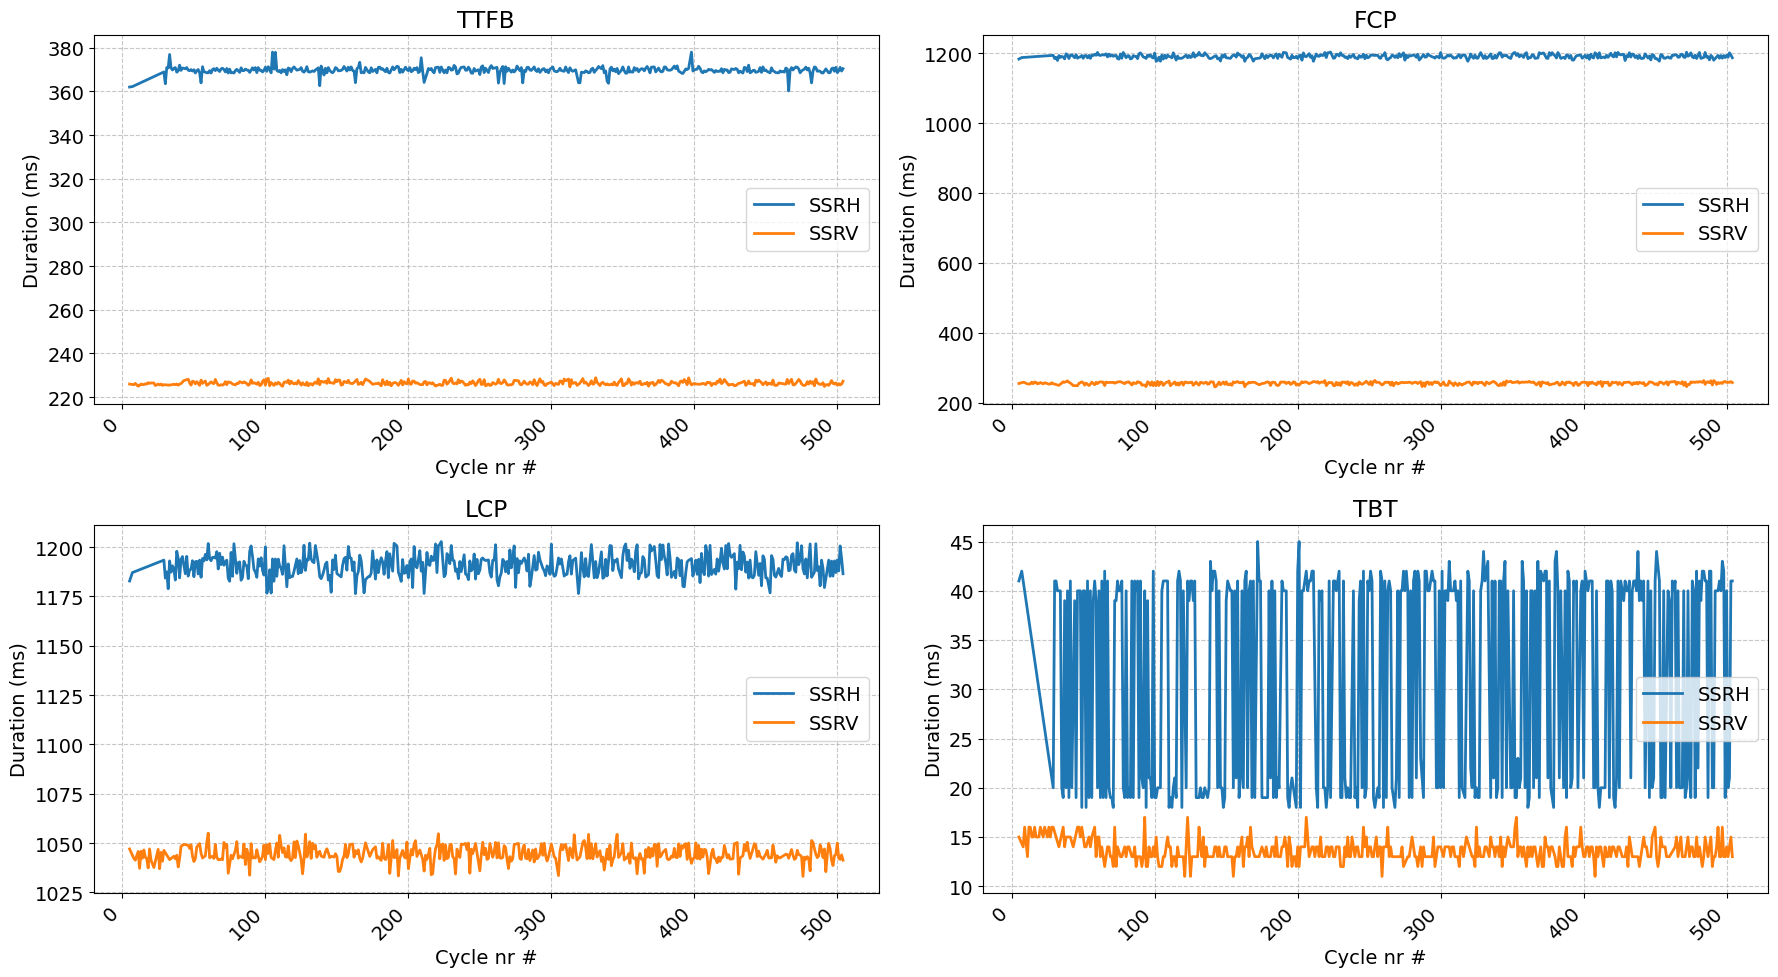

In [32]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18,10))
axes = axes.flatten()

for idx, feature in enumerate(['ttfb','fcp','lcp', 'tbt']):
    ax = axes[idx]
    
    for name, df in dfs.items():
        ax.plot(df[feature], 
                label=name, linewidth=2)
    
    ax.set_title(feature.upper())
    ax.set_xlabel('Cycle nr #')
    ax.set_ylabel('Duration (ms)')
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend()
    
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

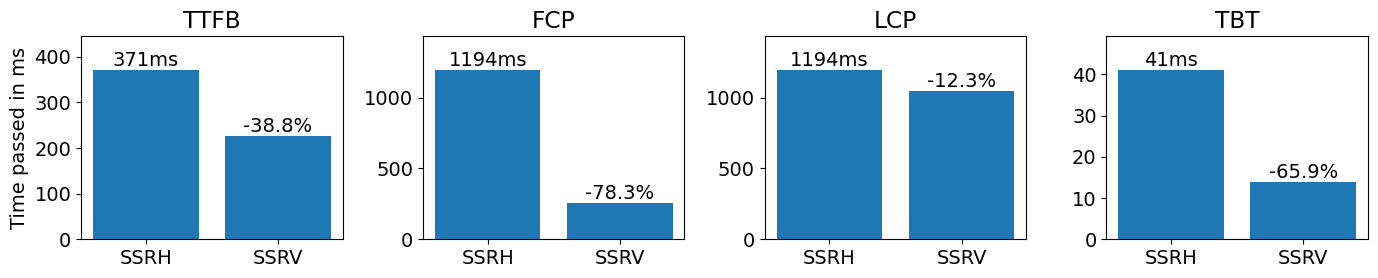

In [33]:
fig, axes = plt.subplots(ncols=len(target_features), figsize=(14, 3))
plt.subplots_adjust(hspace=0.3, wspace=0.3, top=0.95, bottom=0.05)

for idx, feature in enumerate(target_features):
    percentiles = {d: dfs[d][feature].quantile(0.75) for d in dfs}
    bars = axes[idx].bar(percentiles.keys(), percentiles.values())
    baseline = list(percentiles.values())[0]

    max_height = max(percentiles.values())
    axes[idx].set_ylim(0, max_height * 1.2)
    
    for i, bar in enumerate(bars):
        percentage = ((bar.get_height() / baseline) - 1) * 100
        label = f'{int(round(bar.get_height(), 0))}ms' if (i == 0 or bar.get_height() == 0) else f'{percentage:+.1f}%'
        axes[idx].text(bar.get_x() + bar.get_width()/2., bar.get_height(), label, ha='center', va='bottom')
    
    axes[idx].set_title(feature.upper())
    if idx == 0:
        axes[idx].set_ylabel('Time passed in ms')

plt.tight_layout()
plt.show()

## HEAVY THROTTLED Comparison

In [34]:
target_features = ['tbt','ttfb', 'fcp', 'tti', 'lcp']

dirty_dfs =	{
  "SSRH": pd.read_csv(f'{path}2024-12-17T14:52:01.359Z_results-ssrh-sd-throttled-heavy.csv', sep=',').iloc[5:],
  "SSRV": pd.read_csv(f'{path}2024-12-17T20:20:42.349Z_results-ssrv-sd-throttled-heavy.csv', sep=',').iloc[5:],
}

masks = {}
dfs = {}

for name, df in dirty_dfs.items():
    mask = detect_outliers(df, target_features)
    masks[name] = mask
    dfs[name] = df[mask].copy()

### Comparing the different metrics


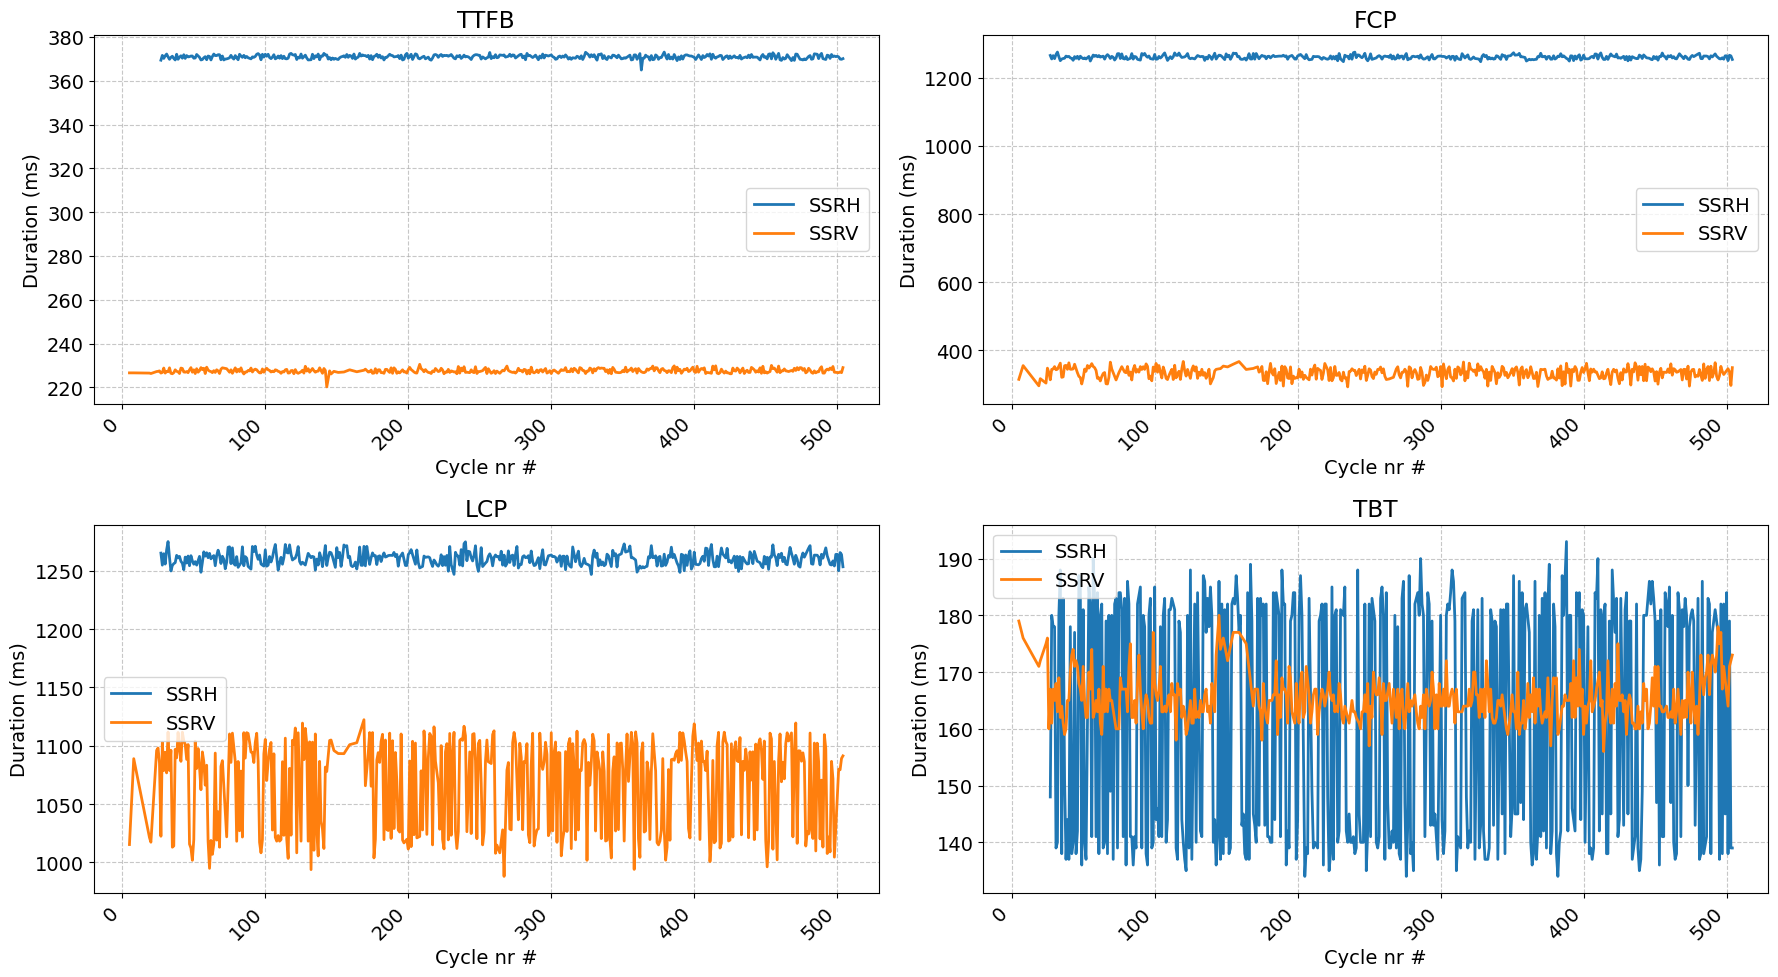

In [35]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 10))
axes = axes.flatten()

for idx, feature in enumerate(['ttfb','fcp','lcp', 'tbt']):
    ax = axes[idx]
    
    for name, df in dfs.items():
        ax.plot(df[feature], 
                label=name, linewidth=2)
    
    ax.set_title(feature.upper())
    ax.set_xlabel('Cycle nr #')
    ax.set_ylabel('Duration (ms)')
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend()
    
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

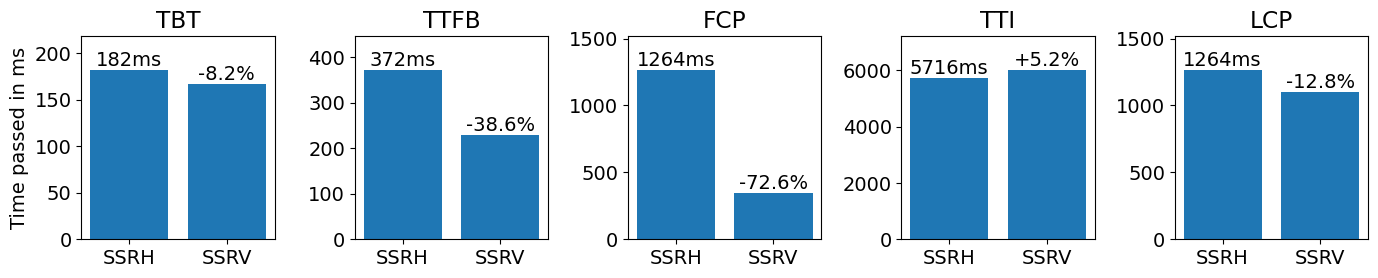

In [36]:
fig, axes = plt.subplots(ncols=len(target_features), figsize=(14, 3))
plt.subplots_adjust(hspace=0.3, wspace=0.3, top=0.95, bottom=0.05)

for idx, feature in enumerate(target_features):
    percentiles = {d: dfs[d][feature].quantile(0.75) for d in dfs}
    bars = axes[idx].bar(percentiles.keys(), percentiles.values())
    baseline = list(percentiles.values())[0]

    max_height = max(percentiles.values())
    axes[idx].set_ylim(0, max_height * 1.2)
    
    for i, bar in enumerate(bars):
        percentage = ((bar.get_height() / baseline) - 1) * 100
        label = f'{int(round(bar.get_height(), 0))}ms' if (i == 0 or bar.get_height() == 0) else f'{percentage:+.1f}%'
        axes[idx].text(bar.get_x() + bar.get_width()/2., bar.get_height(), label, ha='center', va='bottom')
    
    axes[idx].set_title(feature.upper())
    if idx == 0:
        axes[idx].set_ylabel('Time passed in ms')

plt.tight_layout()
plt.show()